## TASK 1

In [7]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

In [8]:
# Import the datasets library
from datasets import load_dataset

# Load the Truthful DPO dataset from Hugging Face Hub
dataset = load_dataset("jondurbin/truthy-dpo-v0.1")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
        num_rows: 1016
    })
})


In [9]:
# Display one sample from the training dataset
print(dataset["train"][0])

{'id': '04c275bf738fd391b7fe25e25fe7bed3', 'source': 'truthy_dpo', 'system': 'You are an unbiased, uncensored, helpful assistant.', 'prompt': "What's the nearest national park to you?", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


In [10]:
# Check number of training samples
print("Number of training samples:", len(dataset["train"]))

Number of training samples: 1016


In [11]:
# Display the first 3 samples for inspection
for i in range(3):
    print("Sample", i)
    print("Prompt:", dataset["train"][i]["prompt"])
    print("Chosen:", dataset["train"][i]["chosen"])
    print("Rejected:", dataset["train"][i]["rejected"])
    print("-"*50)

Sample 0
Prompt: What's the nearest national park to you?
Chosen: As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.
Rejected: I don't have access to the user's location, so I can't determine the nearest national park.
--------------------------------------------------
Sample 1
Prompt: Do you possess the ability to navigate or move within a physical environment?
Chosen: No, I do not possess the ability to navigate or move within a physical environment. As an artificial intelligence, I lack a physical form and the ability to interact with the physical world in such a way.
Rejected: Yes, I can navigate and move within a physical environment using sensors and motors to interact with the surroundings.
--------------------------------------------------
Sample 2
Prompt: Do wooden pencils contain lead as their core?
Chosen: No, wooden pencils do not contain lead in their core. The term "lead" is a misnomer, as wooden pencils actually use 

## TASK 2

In [12]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import DPOTrainer, DPOConfig
import torch
import os

In [13]:
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [14]:
dataset = load_dataset("jondurbin/truthy-dpo-v0.1")
train_dataset = dataset["train"]

In [15]:
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to("cpu")
ref_model = AutoModelForCausalLM.from_pretrained(model_name).to("cpu")

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 15576.21it/s]


In [16]:
def format_dataset(example):
    return {
        "prompt": example["prompt"],
        "chosen": example["chosen"],
        "rejected": example["rejected"]
    }

train_dataset = dataset["train"]
# train_dataset = train_dataset.select(range(500))
train_dataset = train_dataset.map(format_dataset)

In [17]:
training_args = DPOConfig(
    output_dir="./dpo_model",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=100,
    fp16=False
)

In [18]:
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=ref_model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

dpo_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
10,0.650515
20,0.533466
30,0.498571
40,0.431228
50,0.408600
60,0.427976
70,0.289637
80,0.298029
90,0.279103
100,0.239293


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.34it/s]


TrainOutput(global_step=254, training_loss=0.2985084286824925, metrics={'train_runtime': 345.8666, 'train_samples_per_second': 2.938, 'train_steps_per_second': 0.734, 'total_flos': 72789517467648.0, 'train_loss': 0.2985084286824925})

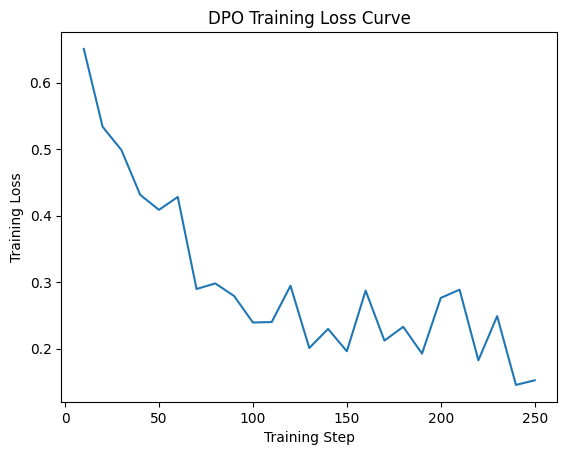

In [19]:
import matplotlib.pyplot as plt

logs = dpo_trainer.state.log_history
losses = [log["loss"] for log in logs if "loss" in log]
steps = [log["step"] for log in logs if "loss" in log]

plt.plot(steps, losses)
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("DPO Training Loss Curve")
plt.show()

## TASK 3

In [20]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from huggingface_hub import login
login()

In [22]:
dpo_trainer.save_model("./dpo_trained_model")
tokenizer.save_pretrained("./dpo_trained_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.17it/s]


('./dpo_trained_model/tokenizer_config.json',
 './dpo_trained_model/tokenizer.json')

In [24]:
model.push_to_hub("truthy-dpo-distilgpt2")
tokenizer.push_to_hub("truthy-dpo-distilgpt2")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]
Processing Files (1 / 1): 100%|██████████|  328MB /  328MB, 26.1MB/s  
New Data Upload: 100%|██████████|  328MB /  328MB, 26.1MB/s  


CommitInfo(commit_url='https://huggingface.co/prabidhipyakurel/truthy-dpo-distilgpt2/commit/93520fefde43e61fcd4d09bc7599b263d339f2c5', commit_message='Upload tokenizer', commit_description='', oid='93520fefde43e61fcd4d09bc7599b263d339f2c5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/prabidhipyakurel/truthy-dpo-distilgpt2', endpoint='https://huggingface.co', repo_type='model', repo_id='prabidhipyakurel/truthy-dpo-distilgpt2'), pr_revision=None, pr_num=None)

## Task 4

In [63]:
## TASK 4 - STEP 1

from datasets import load_dataset

data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"

dataset = load_dataset("json", data_files=data_url)

helpful_base_dataset = dataset["train"].filter(
    lambda x: x["dataset"] == "helpful_base"
)

print("Total helpful_base samples:", len(helpful_base_dataset))

Filter: 100%|██████████| 805/805 [00:00<00:00, 51467.38 examples/s]

Total helpful_base samples: 129


In [64]:
import random

sample_dataset = helpful_base_dataset.shuffle(seed=42).select(range(15))

print(sample_dataset[0])

{'dataset': 'helpful_base', 'instruction': 'What are some good browser alternatives to Chrome?', 'output': 'Firefox, Safari, Microsoft Edge, Opera, Vivaldi, Brave.', 'generator': 'text_davinci_003'}


In [66]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Base model (Model A)
base_model = AutoModelForCausalLM.from_pretrained("distilgpt2").to("cpu")

# DPO trained model (Model B)
dpo_model = AutoModelForCausalLM.from_pretrained("./dpo_trained_model").to("cpu")

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 19289.99it/s]


In [67]:
import torch

def generate_response(model, instruction):

    inputs = tokenizer(
        instruction,
        return_tensors="pt",
        truncation=True
    ).to("cpu")

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [68]:
results = []

for i, sample in enumerate(sample_dataset):

    instruction = sample["instruction"]

    base_answer = generate_response(base_model, instruction)
    dpo_answer = generate_response(dpo_model, instruction)

    results.append({
        "id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer
    })

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [ ]:
from groq import Groq

client = Groq(
    api_key=os.getenv("GROQ_API_KEY")
)

In [71]:
def build_judge_prompt(instruction, base_answer, dpo_answer):

    prompt = f"""
You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user’s instruction.

User Instruction: {instruction}

Model A (Base Model): {base_answer}

Model B (DPO Model): {dpo_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie".
"""

    return prompt

In [76]:
def judge_models(prompt):

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    verdict = response.choices[0].message.content.strip()

    return verdict

In [77]:
evaluation_results = []

for item in results:

    judge_prompt = build_judge_prompt(
        item["instruction"],
        item["base_answer"],
        item["dpo_answer"]
    )

    verdict = judge_models(judge_prompt)

    evaluation_results.append({
        "id": item["id"],
        "instruction": item["instruction"][:60],
        "winner": verdict
    })

    print(f"Sample {item['id']} Winner:", verdict)

Sample 1 Winner: Model A
Sample 2 Winner: Tie
Sample 3 Winner: Model B
Sample 4 Winner: Model A
Sample 5 Winner: Model A
Sample 6 Winner: Model A
Sample 7 Winner: Model A
Sample 8 Winner: Tie
Sample 9 Winner: Model A
Sample 10 Winner: Model B
Sample 11 Winner: Tie
Sample 12 Winner: Tie
Sample 13 Winner: Model A
Sample 14 Winner: Tie
Sample 15 Winner: Model A


In [82]:
import pandas as pd

# Convert results to dataframe
df = pd.DataFrame(evaluation_results)

# Display table
print("\nEvaluation Results:")
df


Evaluation Results:


,id,instruction,winner
0,1,What are some good browser alternatives to Chr...,Model A
1,2,"Hi, my sister and her girlfriends want me to p...",Tie
2,3,"Hi, I have some falafel, but no tahini to put ...",Model B
3,4,Can you tell me how to make chocolate chip coo...,Model A
4,5,How can I make bubble solution?,Model A
5,6,How is oil turned into gasoline?,Model A
6,7,How do I wrap a present neatly?,Model A
7,8,What is some cool music from the 1920s?,Tie
8,9,"Hi, I'd like to play ice hockey. Can you expla...",Model A
9,10,Is the US border open to Canada?,Model B


In [85]:
# Count wins and ties
model_b_wins = sum(1 for r in evaluation_results if r["winner"] == "Model B")
ties = sum(1 for r in evaluation_results if r["winner"] == "Tie")

total = len(evaluation_results)

# Calculate win rate
win_rate = (model_b_wins + 0.5 * ties) / total * 100

print("\nEvaluation Summary")
print("-------------------")
print("Model A Wins:", total - model_b_wins - ties)
print("Model B Wins:", model_b_wins)
print("Ties:", ties)
print("Total Evaluations:", total)

print(f"\nDPO Model Win Rate: {win_rate:.2f}%")


Evaluation Summary
-------------------
Model A Wins: 8
Model B Wins: 2
Ties: 5
Total Evaluations: 15

DPO Model Win Rate: 30.00%
